# Correlation with LLM-measured 3E

In [1]:
# %pip install -q pingouin
# %pip install -q seaborn

# Finding correlation

## Load Human Judge ratings

In [2]:
import pandas as pd
# Load the first CSV file
merged_by_ty = pd.read_csv('data/merged_by_ty.csv')
merged_by_ty

,VIDEO_NUM,P_ID,ARM,FIRST_SECOND,CASE_TITLE,P_BACKGROUND,SP_NAME,REVIEWER_NAME,REVIEWER_TYPE,Q1,...,Q14,Q15,Q16,Q17,Q18,Q19,QSUM_EMPOWER,QSUM_EXPLICIT,QSUM_EMPATHY,QSUM_ALL
0,video1829885929,1,S,First,Pat Smith,Student,SP11,SP11,SP,1,...,4,4,1,5,8,4,0.400,0.885714,0.733333,0.634783
1,video8829885929,1,S,Second,Lois Bell,Student,SP11,SP11,SP,2,...,3,4,4,5,7,5,0.675,1.000000,0.766667,0.782609
2,video1757986894,0,C,First,Lois Bell,PA,SP0,SP0,SP,5,...,5,5,4,5,10,10,0.675,0.857143,0.966667,0.834783
3,video2757986894,0,C,Second,Pat Smith,PA,SP0,SP0,SP,5,...,5,5,4,5,10,10,0.875,0.885714,0.966667,0.913043
4,video1631554860,2,S,First,Jill Cooper,Student,SP4,SP4,SP,5,...,2,3,5,2,2,2,0.550,0.828571,0.466667,0.582609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,video9840306571,35,S,Second,Lois Bell,Student,SP9,TP1,TP,4,...,4,4,2,4,8,7,0.600,0.828571,0.733333,0.713043
502,video9946328095,52,S,Second,Pat Smith,Doctor,SP9,TP2,TP,4,...,1,2,3,2,3,3,0.425,0.657143,0.366667,0.469565
503,video9946328095,52,S,Second,Pat Smith,Doctor,SP9,TP0,TP,1,...,3,3,4,3,6,4,0.325,0.600000,0.633333,0.495652
504,video9946328095,52,S,Second,Pat Smith,Doctor,SP9,TP3,TP,1,...,2,3,3,3,4,5,0.350,0.828571,0.500000,0.547826


## SP+TP

In [3]:
sp_tp_data = merged_by_ty[
    ['P_ID', 'ARM', 'FIRST_SECOND', 'REVIEWER_NAME', 'QSUM_EMPOWER', 'QSUM_EXPLICIT', 'QSUM_EMPATHY', 'QSUM_ALL']
].copy()

sp_tp_data["UNIQUE_REVIEWER"] = sp_tp_data["REVIEWER_NAME"].str.replace(
    r"SP\d+", "SP", regex=True
)

sp_tp_data = sp_tp_data.drop(columns=["REVIEWER_NAME"])

In [4]:
grouped_mean = sp_tp_data.groupby(['P_ID', 'ARM', 'FIRST_SECOND', 'UNIQUE_REVIEWER']).mean().reset_index()
grouped_mean

,P_ID,ARM,FIRST_SECOND,UNIQUE_REVIEWER,QSUM_EMPOWER,QSUM_EXPLICIT,QSUM_EMPATHY,QSUM_ALL
0,0,C,First,SP,0.675,0.857143,0.966667,0.834783
1,0,C,First,TP0,0.800,0.885714,0.900000,0.852174
2,0,C,First,TP1,0.800,0.914286,0.933333,0.886957
3,0,C,First,TP2,0.850,0.942857,1.000000,0.930435
4,0,C,First,TP3,0.475,0.828571,0.733333,0.678261
...,...,...,...,...,...,...,...,...
501,64,C,Second,SP,0.525,0.571429,0.400000,0.504348
502,64,C,Second,TP0,0.550,0.828571,0.433333,0.600000
503,64,C,Second,TP1,0.525,0.771429,0.733333,0.678261
504,64,C,Second,TP2,0.375,0.857143,0.600000,0.600000


In [5]:
# Columns you want to spread by reviewer
value_cols = ["QSUM_EMPOWER", "QSUM_EXPLICIT", "QSUM_EMPATHY", "QSUM_ALL"]
reviewers = ['SP', 'TP0', 'TP1', 'TP2', 'TP3']

# Keep one row per P_ID + FIRST_SECOND (+ ARM if you want to keep it)
grouped_mean_wide = (
    grouped_mean.pivot_table(
        index=["P_ID", "ARM", "FIRST_SECOND"],
        columns="UNIQUE_REVIEWER",
        values=value_cols,
        aggfunc="first"
    )
)

# Flatten the multi-index columns: (QSUM_EMPOWER, SP) -> QSUM_EMPOWER_SP
grouped_mean_wide.columns = [f"{metric}_{reviewer}" for metric, reviewer in grouped_mean_wide.columns]

# Back to normal columns
grouped_mean_wide = grouped_mean_wide.reset_index()


# Normalize all score columns (LLM + QSUM) to [0, 1] to avoid individual bias

cols_to_normalize = [
    'QSUM_ALL_SP', 'QSUM_ALL_TP0', 'QSUM_ALL_TP1', 'QSUM_ALL_TP2', 'QSUM_ALL_TP3',
    'QSUM_EMPATHY_SP', 'QSUM_EMPATHY_TP0', 'QSUM_EMPATHY_TP1', 'QSUM_EMPATHY_TP2', 'QSUM_EMPATHY_TP3',
    'QSUM_EMPOWER_SP', 'QSUM_EMPOWER_TP0', 'QSUM_EMPOWER_TP1', 'QSUM_EMPOWER_TP2', 'QSUM_EMPOWER_TP3',
    'QSUM_EXPLICIT_SP', 'QSUM_EXPLICIT_TP0', 'QSUM_EXPLICIT_TP1', 'QSUM_EXPLICIT_TP2', 'QSUM_EXPLICIT_TP3'
]

for col in cols_to_normalize:
    min_val = grouped_mean_wide[col].min()
    max_val = grouped_mean_wide[col].max()
    den = max_val - min_val
    
    if den != 0:
        grouped_mean_wide[col] = (grouped_mean_wide[col] - min_val) / den
    else:
        grouped_mean_wide[col] = 0

# Compute mean across reviewers for each metric
for m in value_cols:
    cols = [f"{m}_{r}" for r in reviewers]
    grouped_mean_wide[f"{m}_MEAN"] = grouped_mean_wide[cols].mean(axis=1)

grouped_mean_wide

,P_ID,ARM,FIRST_SECOND,QSUM_ALL_SP,QSUM_ALL_TP0,QSUM_ALL_TP1,QSUM_ALL_TP2,QSUM_ALL_TP3,QSUM_EMPATHY_SP,QSUM_EMPATHY_TP0,...,QSUM_EMPOWER_TP3,QSUM_EXPLICIT_SP,QSUM_EXPLICIT_TP0,QSUM_EXPLICIT_TP1,QSUM_EXPLICIT_TP2,QSUM_EXPLICIT_TP3,QSUM_EMPOWER_MEAN,QSUM_EXPLICIT_MEAN,QSUM_EMPATHY_MEAN,QSUM_ALL_MEAN
0,0,C,First,0.776471,0.873563,0.964912,0.987342,0.683333,0.958333,0.88,...,0.48,0.791667,0.846154,0.866667,0.913043,0.7500,0.742040,0.833506,0.895987,0.857124
1,0,C,Second,0.882353,0.977011,0.982456,0.924051,0.750000,0.958333,1.00,...,0.68,0.833333,0.961538,1.000000,0.782609,0.6250,0.800525,0.840496,0.949561,0.903174
2,1,S,First,0.505882,0.448276,0.543860,0.240506,0.383333,0.666667,0.44,...,0.24,0.833333,0.653846,0.400000,0.521739,0.5000,0.264614,0.581784,0.471880,0.424372
3,1,S,Second,0.705882,0.356322,0.438596,0.316456,0.450000,0.708333,0.40,...,0.04,1.000000,0.461538,0.533333,0.652174,0.7500,0.298867,0.679409,0.455170,0.453451
4,2,S,First,0.435294,0.517241,0.789474,0.848101,0.650000,0.333333,0.20,...,0.48,0.750000,0.615385,0.600000,0.913043,0.6250,0.639668,0.700686,0.575419,0.648022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,61,C,Second,0.941176,0.655172,0.684211,0.911392,0.683333,1.000000,0.52,...,0.44,0.958333,0.884615,0.600000,1.000000,0.9375,0.628240,0.876090,0.763649,0.775057
98,62,C,First,0.788235,0.574713,0.842105,0.822785,0.883333,1.000000,0.48,...,0.68,0.750000,0.730769,0.866667,0.956522,1.0000,0.636920,0.860792,0.822376,0.782234
99,62,C,Second,0.800000,0.586207,0.684211,0.797468,1.000000,1.000000,0.60,...,1.00,0.750000,0.346154,0.466667,0.739130,0.8125,0.816635,0.622890,0.795810,0.773577
100,64,C,First,0.305882,0.540230,0.842105,0.481013,0.750000,0.250000,0.40,...,0.48,0.333333,0.615385,0.733333,0.260870,0.8125,0.531684,0.551084,0.597850,0.583846


In [6]:
grouped_mean_wide.dropna()

,P_ID,ARM,FIRST_SECOND,QSUM_ALL_SP,QSUM_ALL_TP0,QSUM_ALL_TP1,QSUM_ALL_TP2,QSUM_ALL_TP3,QSUM_EMPATHY_SP,QSUM_EMPATHY_TP0,...,QSUM_EMPOWER_TP3,QSUM_EXPLICIT_SP,QSUM_EXPLICIT_TP0,QSUM_EXPLICIT_TP1,QSUM_EXPLICIT_TP2,QSUM_EXPLICIT_TP3,QSUM_EMPOWER_MEAN,QSUM_EXPLICIT_MEAN,QSUM_EMPATHY_MEAN,QSUM_ALL_MEAN
0,0,C,First,0.776471,0.873563,0.964912,0.987342,0.683333,0.958333,0.88,...,0.48,0.791667,0.846154,0.866667,0.913043,0.7500,0.742040,0.833506,0.895987,0.857124
1,0,C,Second,0.882353,0.977011,0.982456,0.924051,0.750000,0.958333,1.00,...,0.68,0.833333,0.961538,1.000000,0.782609,0.6250,0.800525,0.840496,0.949561,0.903174
2,1,S,First,0.505882,0.448276,0.543860,0.240506,0.383333,0.666667,0.44,...,0.24,0.833333,0.653846,0.400000,0.521739,0.5000,0.264614,0.581784,0.471880,0.424372
3,1,S,Second,0.705882,0.356322,0.438596,0.316456,0.450000,0.708333,0.40,...,0.04,1.000000,0.461538,0.533333,0.652174,0.7500,0.298867,0.679409,0.455170,0.453451
4,2,S,First,0.435294,0.517241,0.789474,0.848101,0.650000,0.333333,0.20,...,0.48,0.750000,0.615385,0.600000,0.913043,0.6250,0.639668,0.700686,0.575419,0.648022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,61,C,Second,0.941176,0.655172,0.684211,0.911392,0.683333,1.000000,0.52,...,0.44,0.958333,0.884615,0.600000,1.000000,0.9375,0.628240,0.876090,0.763649,0.775057
98,62,C,First,0.788235,0.574713,0.842105,0.822785,0.883333,1.000000,0.48,...,0.68,0.750000,0.730769,0.866667,0.956522,1.0000,0.636920,0.860792,0.822376,0.782234
99,62,C,Second,0.800000,0.586207,0.684211,0.797468,1.000000,1.000000,0.60,...,1.00,0.750000,0.346154,0.466667,0.739130,0.8125,0.816635,0.622890,0.795810,0.773577
100,64,C,First,0.305882,0.540230,0.842105,0.481013,0.750000,0.250000,0.40,...,0.48,0.333333,0.615385,0.733333,0.260870,0.8125,0.531684,0.551084,0.597850,0.583846


# Load LLM Ratings

In [7]:
!dir data

 Volume in drive C has no label.
 Volume Serial Number is B4B1-43F1

 Directory of C:\Users\young\OneDrive - University of Rochester\Academics\Thesis\SOPHIE2.0-analysis\data

05/27/2026  10:43    <DIR>          .
06/01/2026  12:54    <DIR>          ..
04/15/2026  10:17           594,517 3E_by_llm2.csv
05/27/2026  10:42             7,088 admin_demographic_survey.csv
05/27/2026  10:42             8,503 admin_exit_survey.csv
05/27/2026  10:42            10,278 admin_interactions.csv
05/27/2026  10:42         1,895,355 admin_meeting_feedback.csv
05/27/2026  10:42           563,827 admin_transcripts.csv
05/20/2026  03:23           405,130 llm_ranking_gpt-5.4_low.csv
04/15/2026  10:22            74,935 merged_by_ty.csv
04/15/2026  10:17             4,137 second-first.csv
04/15/2026  17:58           596,156 sophie_1.0_3E_gpt-4.1-mini_None.csv
04/15/2026  17:56           596,068 sophie_1.0_3E_gpt-4.1_None.csv
04/15/2026  18:10           596,043 sophie_1.0_3E_gpt-5-mini_high.csv
04/15/2026  10:

In [8]:
model = "gpt-5.4"
reasoning_effort = "low"
llm_3E = pd.read_csv(f'data/sophie_1.0_3E_{model}_{reasoning_effort}.csv')
llm_3E

,filename,participant,control/sophie,pre/post,word_count,content,LLM_SUM_EMPOWER,LLM_SUM_EXPLICIT,LLM_SUM_EMPATHY,LLM_SUM_ALL
0,p19_post_w_speaker.txt,p19,control,post,1023.0,"Patient: Go.\nDoctor: Hi, Lois. How are you to...",0.400000,0.714286,0.566667,0.541667
1,p23_post_w_speaker.txt,p23,control,post,901.0,"Doctor: All right, go for it. Hello, Jill. How...",0.355556,0.571429,0.333333,0.400000
2,p23_pre_w_speaker.txt,p23,control,pre,745.0,"Doctor: It. What should happen here? Like, sho...",0.200000,0.285714,0.166667,0.208333
3,p24_post_w_speaker.txt,p24,control,post,1361.0,Doctor: The last. Hi. How are you feeling?\nPa...,0.511111,0.485714,0.633333,0.533333
4,p24_pre_w_speaker.txt,p24,control,pre,1068.0,"Doctor: Hi, how are you doing?\nPatient: I'm o...",0.288889,0.571429,0.466667,0.408333
...,...,...,...,...,...,...,...,...,...,...
96,p53_pre_w_speaker.txt,p53,sophie,pre,1416.0,"Patient: Go.\nDoctor: Hi, Joe.\nPatient: Hi.\n...",0.355556,0.742857,0.700000,0.558333
97,p57_post_w_speaker.txt,p57,sophie,post,1532.0,Doctor: Is there. Wait for this one? Is there ...,0.288889,0.428571,0.433333,0.358333
98,p57_pre_w_speaker.txt,p57,sophie,pre,1504.0,"Patient: Go.\nDoctor: Hi, Lois. I received you...",0.466667,0.628571,0.566667,0.533333
99,p7_pre_w_speaker.txt,p7,sophie,pre,1495.0,"Doctor: Thank you. Hello, John.\nPatient: Hey,...",0.466667,0.485714,0.600000,0.483333


In [9]:
llm_3E.columns

Index(['filename', 'participant', 'control/sophie', 'pre/post', 'word_count',
       'content', 'LLM_SUM_EMPOWER', 'LLM_SUM_EXPLICIT', 'LLM_SUM_EMPATHY',
       'LLM_SUM_ALL'],
      dtype='str')

In [10]:
llm_3E = llm_3E[['participant', 'control/sophie', 'pre/post',  'LLM_SUM_EMPOWER', 'LLM_SUM_EXPLICIT', 'LLM_SUM_EMPATHY',
       'LLM_SUM_ALL']]

llm_3E = llm_3E.rename(columns={
    'participant': 'P_ID',
    'control/sophie': 'ARM',
    'pre/post': 'FIRST_SECOND'
})

llm_3E['P_ID'] = llm_3E['P_ID'].astype(str).str.replace('p', '', regex=False).astype(int)
llm_3E['ARM'] = llm_3E['ARM'].replace({'control': 'C', 'sophie': 'S'})
llm_3E['FIRST_SECOND'] = llm_3E['FIRST_SECOND'].replace({'post': 'Second', 'pre': 'First'})

In [11]:
# Normalize selected LLM columns in llm_3E to [0, 1]

cols = [
    'LLM_SUM_EMPOWER',
    'LLM_SUM_EXPLICIT',
    'LLM_SUM_EMPATHY',
    'LLM_SUM_ALL'
]

for col in cols:
    min_val = llm_3E[col].min()
    max_val = llm_3E[col].max()
    den = max_val - min_val
    
    if den != 0:
        llm_3E[col] = (llm_3E[col] - min_val) / den
    else:
        llm_3E[col] = 0

In [12]:
llm_3E

,P_ID,ARM,FIRST_SECOND,LLM_SUM_EMPOWER,LLM_SUM_EXPLICIT,LLM_SUM_EMPATHY,LLM_SUM_ALL
0,19,C,Second,0.391304,0.75,0.571429,0.615385
1,23,C,Second,0.304348,0.50,0.238095,0.353846
2,23,C,First,0.000000,0.00,0.000000,0.000000
3,24,C,Second,0.608696,0.35,0.666667,0.600000
4,24,C,First,0.173913,0.50,0.428571,0.369231
...,...,...,...,...,...,...,...
96,53,S,First,0.304348,0.80,0.761905,0.646154
97,57,S,Second,0.173913,0.25,0.380952,0.276923
98,57,S,First,0.521739,0.60,0.571429,0.600000
99,7,S,First,0.521739,0.35,0.619048,0.507692


# Merge

In [13]:
merged_inner = pd.merge(llm_3E, grouped_mean_wide, on=['P_ID', 'ARM', 'FIRST_SECOND'], how='inner').dropna()
merged_inner

,P_ID,ARM,FIRST_SECOND,LLM_SUM_EMPOWER,LLM_SUM_EXPLICIT,LLM_SUM_EMPATHY,LLM_SUM_ALL,QSUM_ALL_SP,QSUM_ALL_TP0,QSUM_ALL_TP1,...,QSUM_EMPOWER_TP3,QSUM_EXPLICIT_SP,QSUM_EXPLICIT_TP0,QSUM_EXPLICIT_TP1,QSUM_EXPLICIT_TP2,QSUM_EXPLICIT_TP3,QSUM_EMPOWER_MEAN,QSUM_EXPLICIT_MEAN,QSUM_EMPATHY_MEAN,QSUM_ALL_MEAN
0,19,C,Second,0.391304,0.75,0.571429,0.615385,0.529412,0.770115,0.543860,...,0.28,0.708333,0.846154,0.600000,0.782609,0.6875,0.424934,0.724919,0.516311,0.542095
1,23,C,Second,0.304348,0.50,0.238095,0.353846,0.494118,0.287356,0.385965,...,0.32,0.583333,0.423077,0.266667,0.521739,0.3750,0.288650,0.433963,0.435308,0.379311
2,23,C,First,0.000000,0.00,0.000000,0.000000,0.105882,0.252874,0.105263,...,0.52,0.083333,0.384615,0.000000,0.478261,0.5000,0.184251,0.289242,0.279687,0.234238
3,24,C,Second,0.608696,0.35,0.666667,0.600000,0.635294,0.563218,0.684211,...,0.52,0.583333,0.692308,0.600000,0.652174,0.3125,0.551419,0.568063,0.563406,0.577009
4,24,C,First,0.173913,0.50,0.428571,0.369231,0.058824,0.482759,0.350877,...,0.48,0.125000,0.615385,0.333333,0.652174,0.3750,0.343492,0.420178,0.322591,0.367226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,53,S,First,0.304348,0.80,0.761905,0.646154,0.376471,0.218391,0.543860,...,0.48,0.583333,0.346154,0.466667,0.739130,0.8750,0.298372,0.602057,0.503794,0.458883
93,57,S,Second,0.173913,0.25,0.380952,0.276923,0.529412,0.195402,0.614035,...,0.12,0.583333,0.192308,0.666667,0.434783,0.6250,0.289935,0.500418,0.480549,0.421188
94,57,S,First,0.521739,0.60,0.571429,0.600000,0.447059,0.735632,0.421053,...,0.20,0.416667,0.423077,0.133333,0.086957,0.5625,0.417952,0.324507,0.528203,0.432183
95,7,S,First,0.521739,0.35,0.619048,0.507692,0.600000,0.482759,0.438596,...,0.28,0.500000,0.576923,0.333333,0.000000,0.4375,0.378487,0.369551,0.562301,0.439292


# Statistical tests SP+TP

In [14]:
import scipy.stats as stats

In [15]:
stats.pearsonr(merged_inner['QSUM_EMPOWER_MEAN'], merged_inner['LLM_SUM_EMPOWER'])

PearsonRResult(statistic=np.float64(0.7993493047027843), pvalue=np.float64(4.582884458216071e-22))

In [16]:
stats.pearsonr(merged_inner['QSUM_EXPLICIT_MEAN'], merged_inner['LLM_SUM_EXPLICIT'])

PearsonRResult(statistic=np.float64(0.42552907665428746), pvalue=np.float64(1.906759861412813e-05))

In [17]:
stats.pearsonr(merged_inner['QSUM_EMPATHY_MEAN'], merged_inner['LLM_SUM_EMPATHY'])

PearsonRResult(statistic=np.float64(0.6703342929257271), pvalue=np.float64(1.4703895236467332e-13))

In [18]:
stats.pearsonr(merged_inner['QSUM_ALL_MEAN'], merged_inner['LLM_SUM_ALL'])

PearsonRResult(statistic=np.float64(0.7586443832708609), pvalue=np.float64(8.239740187729581e-19))

In [19]:
merged_inner.columns

Index(['P_ID', 'ARM', 'FIRST_SECOND', 'LLM_SUM_EMPOWER', 'LLM_SUM_EXPLICIT',
       'LLM_SUM_EMPATHY', 'LLM_SUM_ALL', 'QSUM_ALL_SP', 'QSUM_ALL_TP0',
       'QSUM_ALL_TP1', 'QSUM_ALL_TP2', 'QSUM_ALL_TP3', 'QSUM_EMPATHY_SP',
       'QSUM_EMPATHY_TP0', 'QSUM_EMPATHY_TP1', 'QSUM_EMPATHY_TP2',
       'QSUM_EMPATHY_TP3', 'QSUM_EMPOWER_SP', 'QSUM_EMPOWER_TP0',
       'QSUM_EMPOWER_TP1', 'QSUM_EMPOWER_TP2', 'QSUM_EMPOWER_TP3',
       'QSUM_EXPLICIT_SP', 'QSUM_EXPLICIT_TP0', 'QSUM_EXPLICIT_TP1',
       'QSUM_EXPLICIT_TP2', 'QSUM_EXPLICIT_TP3', 'QSUM_EMPOWER_MEAN',
       'QSUM_EXPLICIT_MEAN', 'QSUM_EMPATHY_MEAN', 'QSUM_ALL_MEAN'],
      dtype='str')

# Correlation and ICC for leave-one-rater-out

In [28]:
# Install if needed
# !pip install pingouin

import numpy as np
import pandas as pd
import pingouin as pg

# Columns for the overall score
reviewer_cols = {
    "SP": "QSUM_ALL_SP",
    "TP0": "QSUM_ALL_TP0",
    "TP1": "QSUM_ALL_TP1",
    "TP2": "QSUM_ALL_TP2",
    "TP3": "QSUM_ALL_TP3",
    "LLM": "LLM_SUM_ALL",
    "MEAN": "QSUM_ALL_MEAN"
}

human_raters = ["SP", "TP0", "TP1", "TP2", "TP3"]
tp_raters = ["TP0", "TP1", "TP2", "TP3"]

# Keep only needed columns and drop rows with missing values
table_df = merged_inner[[reviewer_cols[r] for r in reviewer_cols]].dropna().copy().reset_index(drop=True)

def compute_icc_a1_with_ci(target_scores, ref_scores):
    icc_input = pd.DataFrame({
        "target_id": np.tile(np.arange(len(target_scores)), 2),
        "rater": ["target"] * len(target_scores) + ["consensus"] * len(ref_scores),
        "score": np.concatenate([target_scores.to_numpy(), ref_scores.to_numpy()])
    })

    icc_res = pg.intraclass_corr(
        data=icc_input,
        targets="target_id",
        raters="rater",
        ratings="score"
    )

    row = icc_res.loc[icc_res["Type"] == "ICC(A,1)"].iloc[0]
    icc_a1 = row["ICC"]
    ci95 = row["CI95"]

    return icc_a1, ci95

rows = []

# Human raters: compare each one to consensus of all other human raters
for target in human_raters:
    ref_raters = [r for r in human_raters if r != target]

    target_scores = table_df[reviewer_cols[target]]
    ref_scores = table_df[[reviewer_cols[r] for r in ref_raters]].mean(axis=1)

    pearson_r = target_scores.corr(ref_scores, method="pearson")
    spearman_rho = target_scores.corr(ref_scores, method="spearman")
    mae = np.mean(np.abs(target_scores - ref_scores))
    icc_a1, ci95 = compute_icc_a1_with_ci(target_scores, ref_scores)

    rows.append({
        "Rater": target,
        "Reference": f"{', '.join(ref_raters)}",
        "Pearson r": pearson_r,
        "Spearman Rho": spearman_rho,
        "MAE": mae,
        "ICC(A,1)": icc_a1,
        "CI95": f"[{ci95[0]:.3f}, {ci95[1]:.3f}]",
    })

# LLM: compare to mean of all human raters
llm_scores = table_df[reviewer_cols["LLM"]]
human_mean_scores = table_df[reviewer_cols["MEAN"]]

pearson_r = llm_scores.corr(human_mean_scores, method="pearson")
spearman_rho = llm_scores.corr(human_mean_scores, method="spearman")
mae = np.mean(np.abs(llm_scores - human_mean_scores))
icc_a1, ci95 = compute_icc_a1_with_ci(llm_scores, human_mean_scores)

rows.append({
    "Rater": "LLM",
    "Reference": "SP, TP0, TP1, TP2, TP3",
    "Pearson r": pearson_r,
    "Spearman Rho": spearman_rho,
    "MAE": mae,
    "ICC(A,1)": icc_a1,
    "CI95": f"[{ci95[0]:.3f}, {ci95[1]:.3f}]",
})


# LLM: compare to mean of all TP raters
tp_mean_scores = table_df[[reviewer_cols[r] for r in tp_raters]].mean(axis=1)

pearson_r = llm_scores.corr(tp_mean_scores, method="pearson")
spearman_rho = llm_scores.corr(tp_mean_scores, method="spearman")
mae = np.mean(np.abs(llm_scores - tp_mean_scores))
icc_a1, ci95 = compute_icc_a1_with_ci(llm_scores, tp_mean_scores)

rows.append({
    "Rater": "LLM",
    "Reference": "TP0, TP1, TP2, TP3",
    "Pearson r": pearson_r,
    "Spearman Rho": spearman_rho,
    "MAE": mae,
    "ICC(A,1)": icc_a1,
    "CI95": f"[{ci95[0]:.3f}, {ci95[1]:.3f}]",
})


leave_one_out_df = pd.DataFrame(rows)

# Rank: higher Pearson better, then higher Spearman, then lower MAE
leave_one_out_df = leave_one_out_df.sort_values(
    by=["Rater"],
    ascending=[True]
).reset_index(drop=True)

leave_one_out_df["Rank"] = np.arange(1, len(leave_one_out_df) + 1)

# Reorder columns
leave_one_out_df = leave_one_out_df[
    [
        "Rater",
        "Reference",
        "Pearson r",
        "Spearman Rho",
        "MAE",
        "ICC(A,1)",
        "CI95"
    ]
]

# Rounded display version
leave_one_out_df_display = leave_one_out_df.copy()
for col in ["Pearson r", "Spearman Rho", "MAE", "ICC(A,1)"]:
    leave_one_out_df_display[col] = leave_one_out_df_display[col].round(3)

print(leave_one_out_df_display)

# Optional LaTeX export
latex_table = leave_one_out_df.to_latex(
    index=False,
    escape=False,
    float_format="%.3f"
)
print(latex_table)

  Rater               Reference  Pearson r  Spearman Rho    MAE  ICC(A,1)  \
0   LLM  SP, TP0, TP1, TP2, TP3      0.759         0.720  0.106     0.746   
1   LLM      TP0, TP1, TP2, TP3      0.719         0.669  0.114     0.702   
2    SP      TP0, TP1, TP2, TP3      0.680         0.667  0.155     0.633   
3   TP0       SP, TP1, TP2, TP3      0.806         0.802  0.111     0.780   
4   TP1       SP, TP0, TP2, TP3      0.625         0.559  0.145     0.596   
5   TP2       SP, TP0, TP1, TP3      0.825         0.810  0.128     0.744   
6   TP3       SP, TP0, TP1, TP2      0.642         0.582  0.126     0.638   

             CI95  
0  [0.640, 0.830]  
1  [0.570, 0.800]  
2  [0.490, 0.740]  
3  [0.680, 0.850]  
4  [0.430, 0.720]  
5  [0.620, 0.830]  
6  [0.500, 0.740]  
\begin{tabular}{llrrrrl}
\toprule
Rater & Reference & Pearson r & Spearman Rho & MAE & ICC(A,1) & CI95 \\
\midrule
LLM & SP, TP0, TP1, TP2, TP3 & 0.759 & 0.720 & 0.106 & 0.746 & [0.640, 0.830] \\
LLM & TP0, TP1, TP2, TP3 & 

In [21]:
merged_inner

,P_ID,ARM,FIRST_SECOND,LLM_SUM_EMPOWER,LLM_SUM_EXPLICIT,LLM_SUM_EMPATHY,LLM_SUM_ALL,QSUM_ALL_SP,QSUM_ALL_TP0,QSUM_ALL_TP1,...,QSUM_EMPOWER_TP3,QSUM_EXPLICIT_SP,QSUM_EXPLICIT_TP0,QSUM_EXPLICIT_TP1,QSUM_EXPLICIT_TP2,QSUM_EXPLICIT_TP3,QSUM_EMPOWER_MEAN,QSUM_EXPLICIT_MEAN,QSUM_EMPATHY_MEAN,QSUM_ALL_MEAN
0,19,C,Second,0.391304,0.75,0.571429,0.615385,0.529412,0.770115,0.543860,...,0.28,0.708333,0.846154,0.600000,0.782609,0.6875,0.424934,0.724919,0.516311,0.542095
1,23,C,Second,0.304348,0.50,0.238095,0.353846,0.494118,0.287356,0.385965,...,0.32,0.583333,0.423077,0.266667,0.521739,0.3750,0.288650,0.433963,0.435308,0.379311
2,23,C,First,0.000000,0.00,0.000000,0.000000,0.105882,0.252874,0.105263,...,0.52,0.083333,0.384615,0.000000,0.478261,0.5000,0.184251,0.289242,0.279687,0.234238
3,24,C,Second,0.608696,0.35,0.666667,0.600000,0.635294,0.563218,0.684211,...,0.52,0.583333,0.692308,0.600000,0.652174,0.3125,0.551419,0.568063,0.563406,0.577009
4,24,C,First,0.173913,0.50,0.428571,0.369231,0.058824,0.482759,0.350877,...,0.48,0.125000,0.615385,0.333333,0.652174,0.3750,0.343492,0.420178,0.322591,0.367226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,53,S,First,0.304348,0.80,0.761905,0.646154,0.376471,0.218391,0.543860,...,0.48,0.583333,0.346154,0.466667,0.739130,0.8750,0.298372,0.602057,0.503794,0.458883
93,57,S,Second,0.173913,0.25,0.380952,0.276923,0.529412,0.195402,0.614035,...,0.12,0.583333,0.192308,0.666667,0.434783,0.6250,0.289935,0.500418,0.480549,0.421188
94,57,S,First,0.521739,0.60,0.571429,0.600000,0.447059,0.735632,0.421053,...,0.20,0.416667,0.423077,0.133333,0.086957,0.5625,0.417952,0.324507,0.528203,0.432183
95,7,S,First,0.521739,0.35,0.619048,0.507692,0.600000,0.482759,0.438596,...,0.28,0.500000,0.576923,0.333333,0.000000,0.4375,0.378487,0.369551,0.562301,0.439292


In [22]:
table_df

,QSUM_ALL_SP,QSUM_ALL_TP0,QSUM_ALL_TP1,QSUM_ALL_TP2,QSUM_ALL_TP3,LLM_SUM_ALL,QSUM_ALL_MEAN
0,0.529412,0.770115,0.543860,0.367089,0.500000,0.615385,0.542095
1,0.494118,0.287356,0.385965,0.329114,0.400000,0.353846,0.379311
2,0.105882,0.252874,0.105263,0.240506,0.466667,0.000000,0.234238
3,0.635294,0.563218,0.684211,0.518987,0.483333,0.600000,0.577009
4,0.058824,0.482759,0.350877,0.493671,0.450000,0.369231,0.367226
...,...,...,...,...,...,...,...
89,0.376471,0.218391,0.543860,0.455696,0.700000,0.646154,0.458883
90,0.529412,0.195402,0.614035,0.367089,0.400000,0.276923,0.421188
91,0.447059,0.735632,0.421053,0.240506,0.316667,0.600000,0.432183
92,0.600000,0.482759,0.438596,0.341772,0.333333,0.507692,0.439292


In [23]:
table_df[reviewer_cols["LLM"]].corr(table_df[reviewer_cols["MEAN"]], method="pearson")

np.float64(0.7586443832708609)

# Correlation visualization

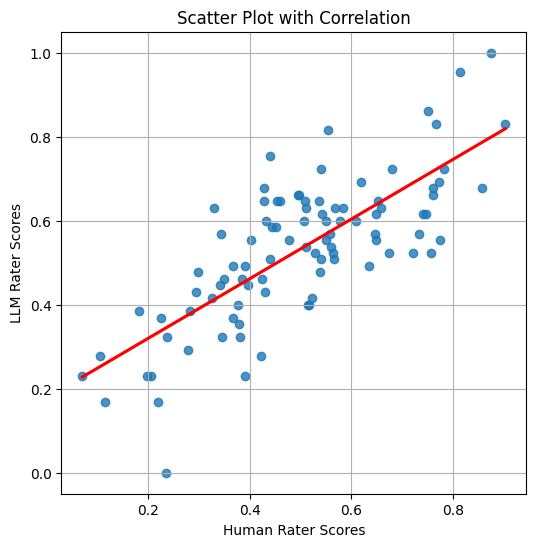

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

rater1 = list(merged_inner['QSUM_ALL_MEAN'])
rater2 = list(merged_inner['LLM_SUM_ALL'])

# Create scatter plot with regression line
plt.figure(figsize=(6,6))
sns.regplot(x=rater1, y=rater2, ci=None, line_kws={"color":"red"})
plt.xlabel("Human Rater Scores")
plt.ylabel("LLM Rater Scores")
plt.title("Scatter Plot with Correlation")
plt.grid(True)

# Display plot
plt.show()

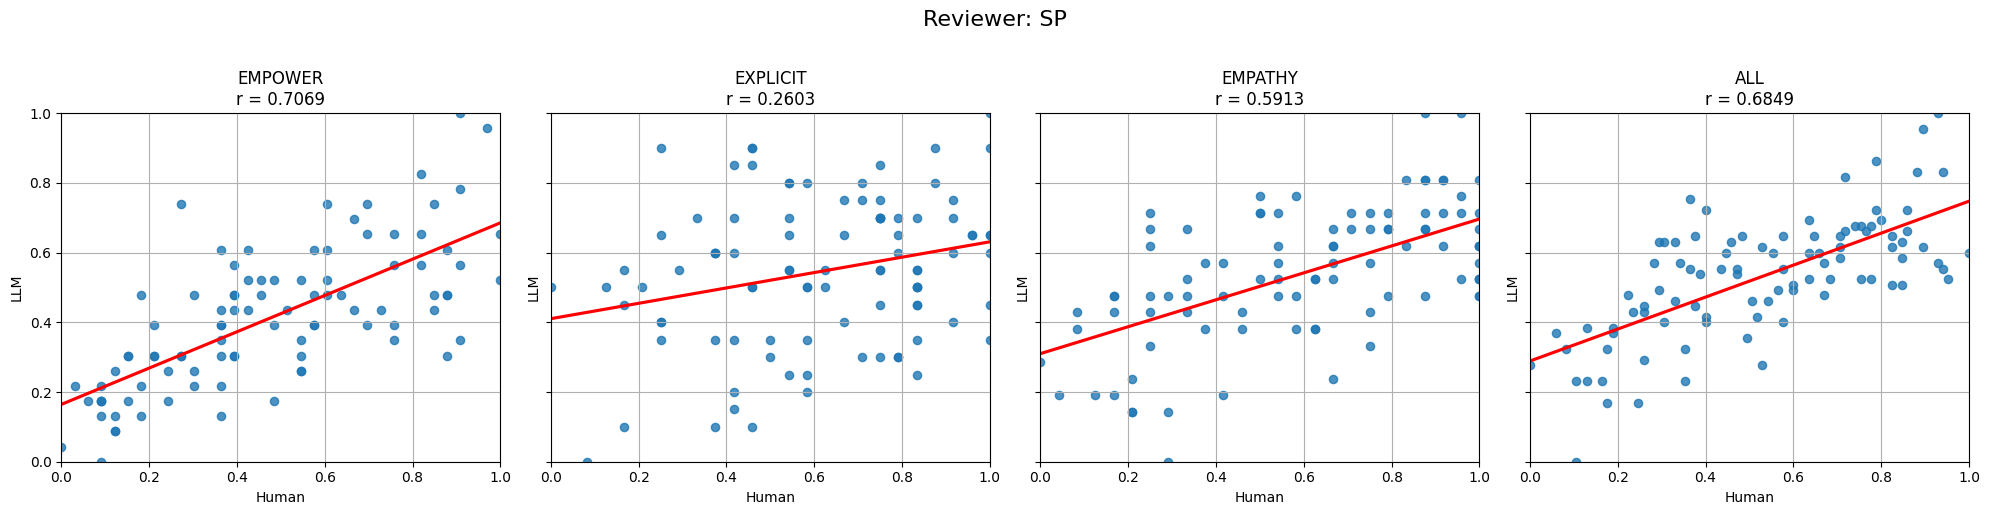

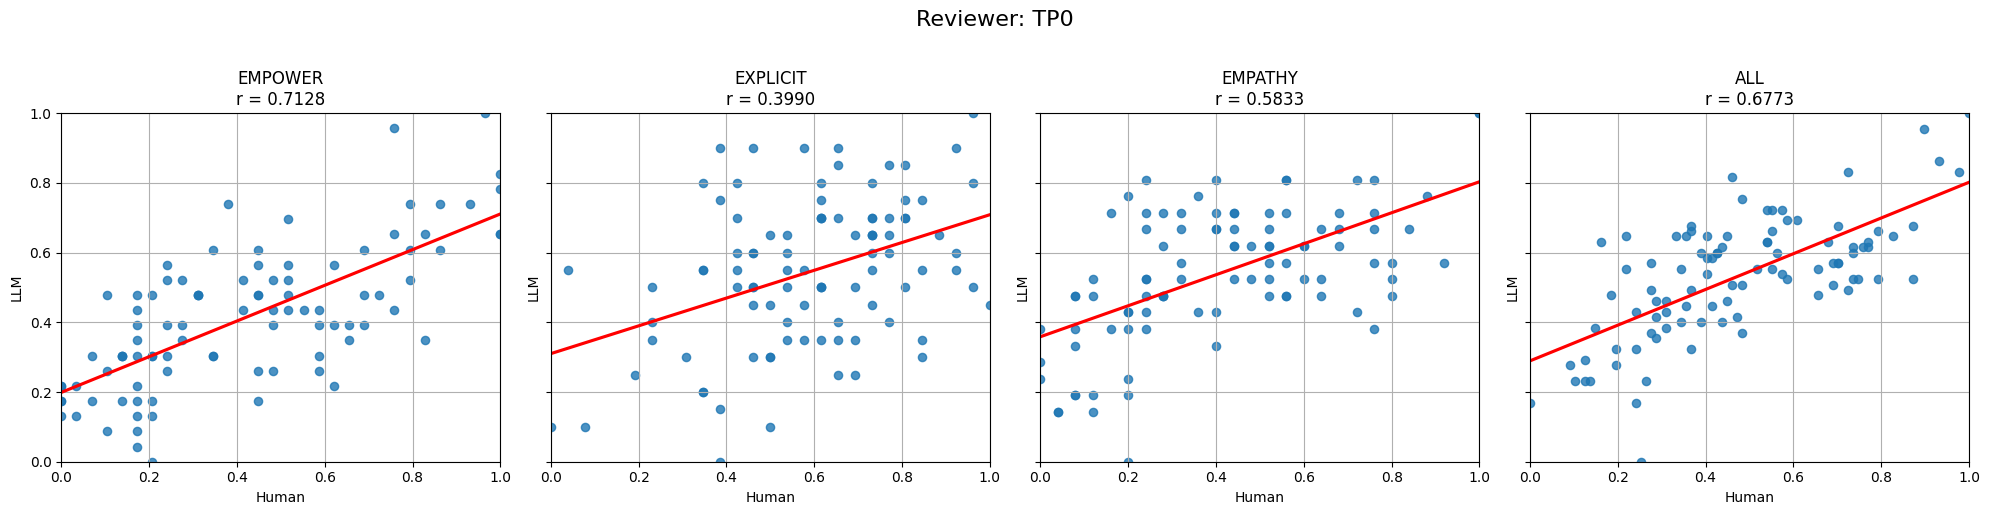

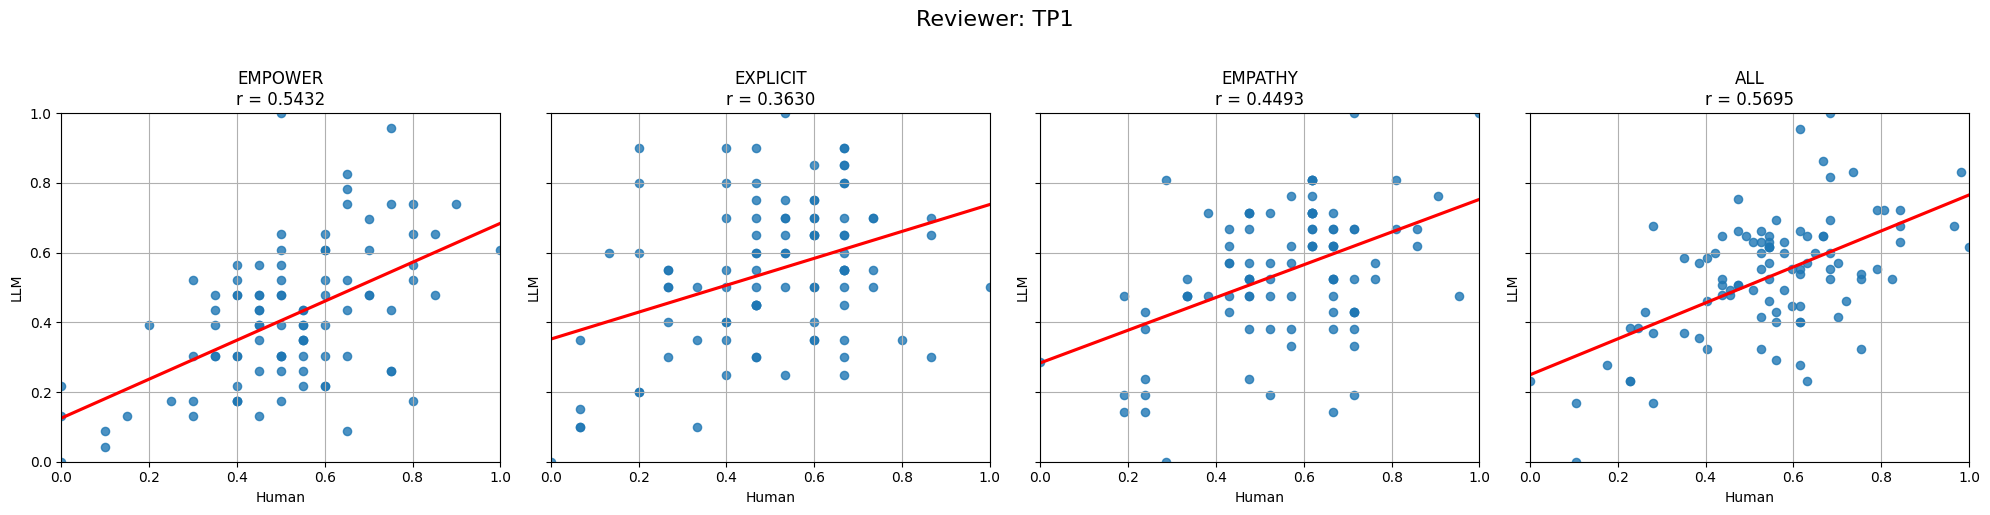

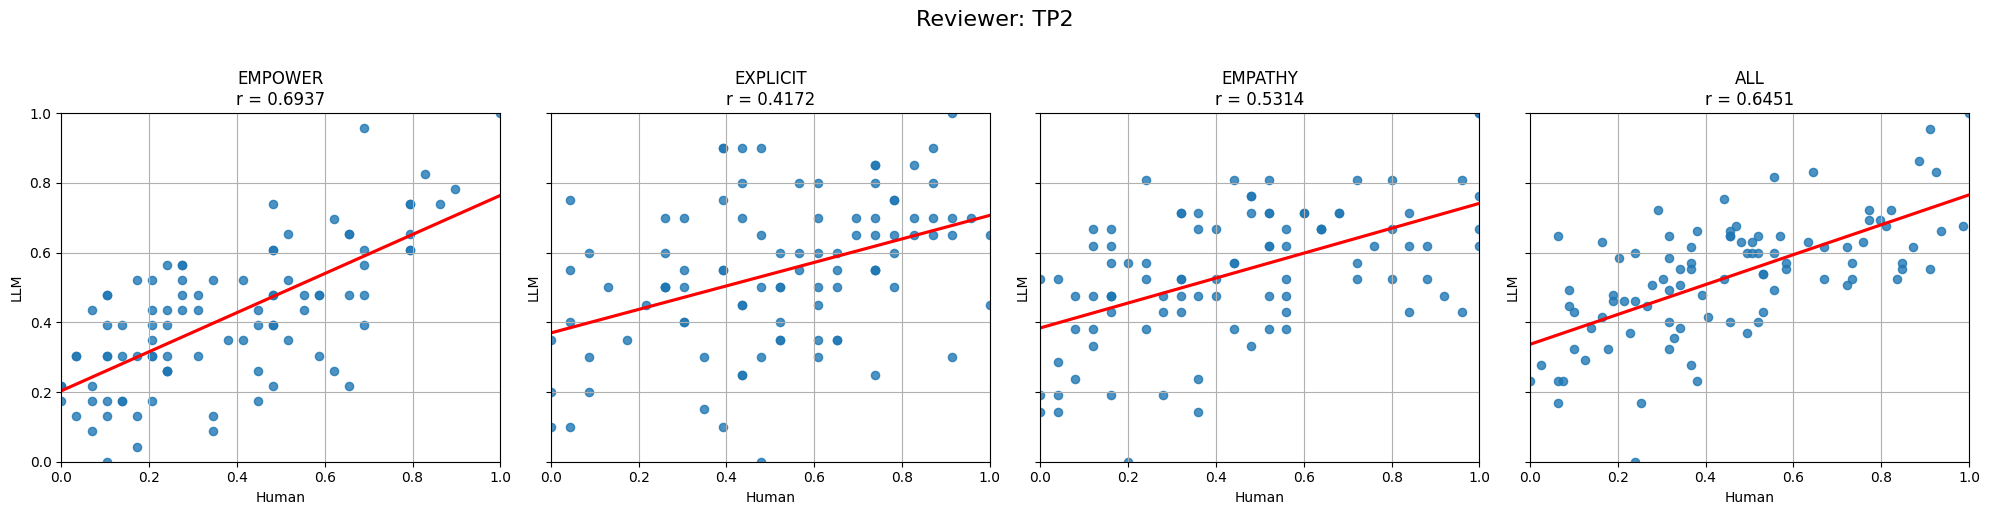

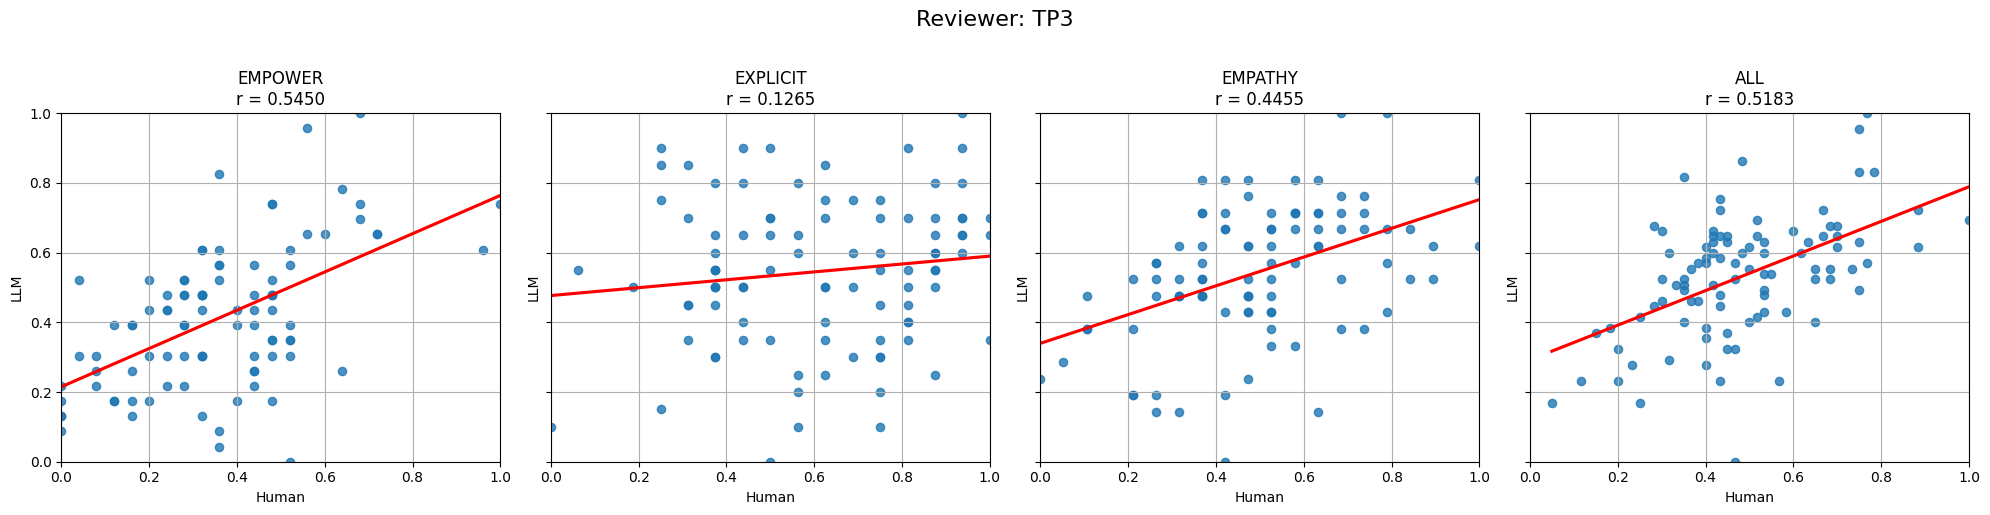

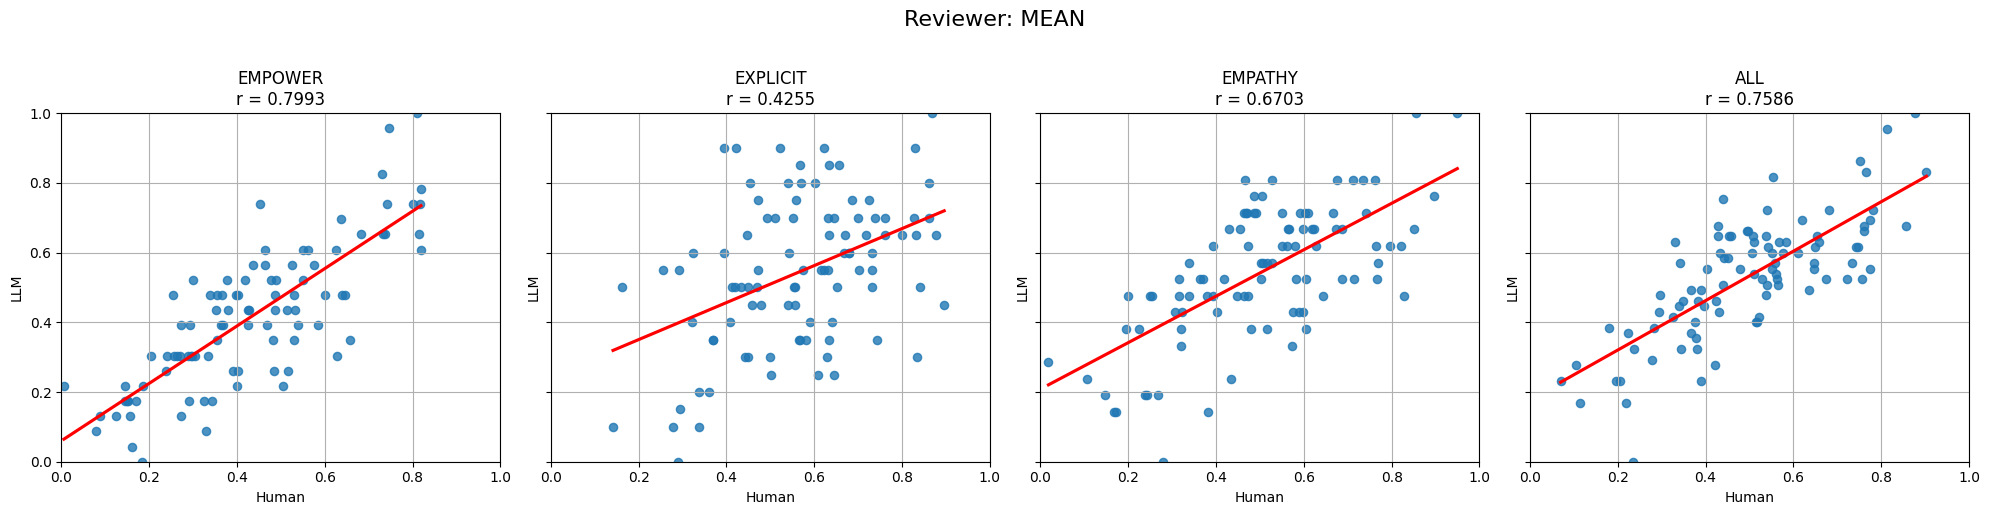

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

reviewers = ['SP', 'TP0', 'TP1', 'TP2', 'TP3', 'MEAN']
metrics = ['EMPOWER', 'EXPLICIT', 'EMPATHY', 'ALL']

for reviewer in reviewers:
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True)

    for ax, metric in zip(axes, metrics):
        h_col = f"QSUM_{metric}_{reviewer}"
        l_col = f"LLM_SUM_{metric}"

        df_plot = merged_inner[[h_col, l_col]].dropna()
        x = df_plot[h_col]
        y = df_plot[l_col]

        if len(df_plot) > 1:
            r_val = np.corrcoef(x, y)[0, 1]
        else:
            r_val = np.nan

        sns.regplot(
            data=df_plot,
            x=h_col,
            y=l_col,
            ci=None,
            scatter_kws={"s": 35},
            line_kws={"color": "red"},
            ax=ax
        )

        max_val = max(x.max(), y.max()) if len(df_plot) > 0 else 1
        ax.set_xlim(0, max_val)
        ax.set_ylim(0, max_val)

        ax.set_xlabel("Human")
        ax.set_ylabel("LLM")
        ax.set_title(f"{metric}\nr = {r_val:.4f}")
        ax.grid(True)

    fig.suptitle(f"Reviewer: {reviewer}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

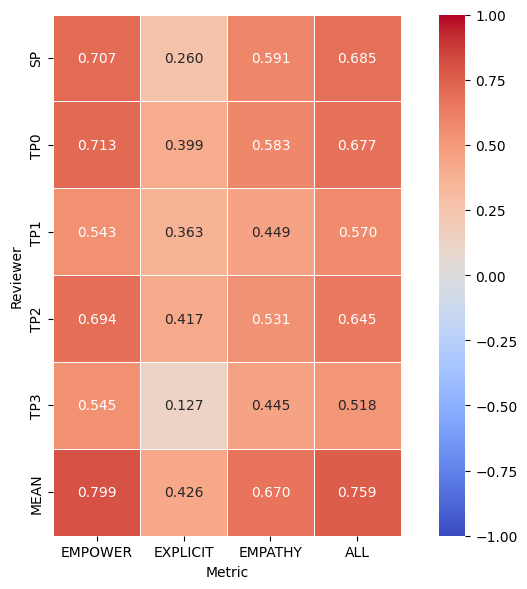

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

reviewers = ['SP', 'TP0', 'TP1', 'TP2', 'TP3', 'MEAN']
metrics = ['EMPOWER', 'EXPLICIT', 'EMPATHY', 'ALL']

# Build correlation table: rows = reviewers, cols = metrics
corr_table = pd.DataFrame(index=reviewers, columns=metrics, dtype=float)

for reviewer in reviewers:
    for metric in metrics:
        h_col = f"QSUM_{metric}_{reviewer}"
        l_col = f"LLM_SUM_{metric}"

        df_plot = merged_inner[[h_col, l_col]].dropna()

        if len(df_plot) > 1:
            corr_table.loc[reviewer, metric] = np.corrcoef(
                df_plot[h_col], df_plot[l_col]
            )[0, 1]
        else:
            corr_table.loc[reviewer, metric] = np.nan

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_table,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)

# plt.title("Correlation of Individual Human Judge vs LLM Scores")
plt.xlabel("Metric")
plt.ylabel("Reviewer")
plt.tight_layout()
plt.savefig("figures/rater_correlation_3E.pdf", bbox_inches="tight")
plt.show()

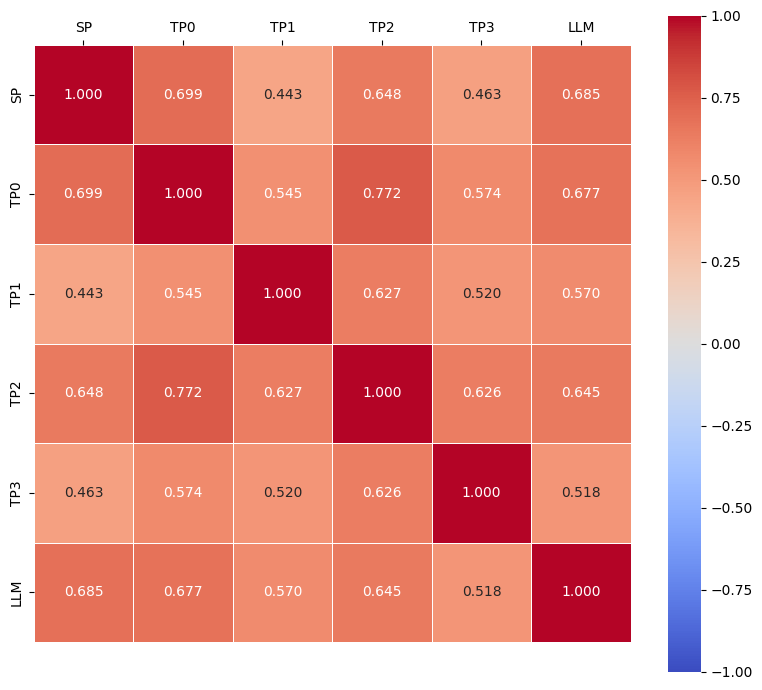

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

reviewer_cols = {
    "SP": "QSUM_ALL_SP",
    "TP0": "QSUM_ALL_TP0",
    "TP1": "QSUM_ALL_TP1",
    "TP2": "QSUM_ALL_TP2",
    "TP3": "QSUM_ALL_TP3",
    "LLM": "LLM_SUM_ALL",
    # "MEAN": "QSUM_ALL_MEAN",
}

corr_df = merged_inner[[col for col in reviewer_cols.values()]].rename(
    columns={v: k for k, v in reviewer_cols.items()}
)

corr_matrix = corr_df.corr(method="pearson") # "spearman", "kendall"

plt.figure(figsize=(8, 7))
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

# Put x-axis labels on top
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x')

# plt.title("Correlation Between Reviewers (ALL)", pad=30)
# Save as PDF
plt.savefig("figures/rater_correlation_heatmap.pdf", bbox_inches="tight")

plt.tight_layout()
plt.show()